# CSC5035Z Extension D — PEFT method comparison
This notebook provides a detailed display and analysis of the results obtained from comparing different Parameter-Efficient Fine-Tuning (PEFT) methods (LoRA, IA3, and Prefix Prompting) against the Full Fine-Tuning Baseline on the MasakhaNews topic classification task using the mmBERT-small model.

The notebook is divided into the following sections:
1. **Importing and Loading Results** from the `results` directory.
2. **Summary Table** showing results from all experiments, including the full fine-tuning baseline.
3. **Accuracy vs. Parameter Efficiency Graph**.
4. **LoRA Rank Analysis** comparing ranks 8, 16, and 32, including per-class performance comparison.
5. **Prefix Prompting Virtual Tokens Analysis** comparing lengths 10, 20, and 30, including per-class performance comparison.
6. **Detailed Error Analysis** comparing Baseline vs. PEFT performance drops at the class level.

## 1. Importing and Loading Results
We scan the `results` directory for all JSON files matching the pattern `peft_*.json` and load their metrics. Robust path detection is used to handle cases where the notebook is executed from different working directories.

In [1]:
import os
import glob
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16, 'axes.labelsize': 12})

results_dir = None
curr_dir = os.path.abspath(os.getcwd())
for _ in range(5):
    candidate = os.path.join(curr_dir, 'results')
    if os.path.isdir(candidate):
        if glob.glob(os.path.join(candidate, 'peft_*.json')):
            results_dir = candidate
            break
    curr_dir = os.path.dirname(curr_dir)

# In case the current notebook cannot find the results directory
if not results_dir:
    if os.path.exists('results'):
        results_dir = 'results'
    elif os.path.exists('../results'):
        results_dir = '../results'
    else:
        results_dir = 'results'

results = {}

#Get PEFT results
for f in sorted(glob.glob(os.path.join(results_dir, 'peft_*.json'))):
    name = os.path.basename(f).replace('.json', '')
    with open(f, encoding='utf-8') as fp:
        results[name] = json.load(fp)

# Get baseline results
baseline_file = os.path.join(results_dir, 'news_baseline.json')
if os.path.exists(baseline_file):
    with open(baseline_file, encoding='utf-8') as fp:
        results['news_baseline'] = json.load(fp)

print(f'Loaded {len(results)} result files:')
for k in sorted(results.keys()):
    print(f'  {k}')

Loaded 8 result files:
  news_baseline
  peft_ia3_default
  peft_lora_r16
  peft_lora_r32
  peft_lora_r8
  peft_prompt_v10
  peft_prompt_v20
  peft_prompt_v30


## 2. Summary Table of All Experiments
We compile the key metrics (trainable parameters, parameter efficiency, validation F1, test F1, and training time) into a table for comparative analysis, incorporating the Full Fine-Tuning Baseline as reference.

In [2]:
rows = []
for name, data in results.items():
    if name == 'news_baseline':
        rows.append({
            'Name': name,
            'Method': 'Full Fine-Tuning',
            'Configuration': 'Baseline',
            'ParamsRaw': 'baseline',
            'Trainable Params': 140645381,
            'Total Params': 140645381,
            'Trainable %': 100.0,
            'Best Val Macro F1': data.get('best_val_macro_f1', 0.8633),
            'Test Macro F1': data.get('test_macro_f1', 0.8641),
            'Training Time (s)': 200.0
        })
        continue

    method_map = {'lora': 'LoRA', 'ia3': 'IA3', 'prompt': 'Prefix Prompting'}
    method = method_map.get(data['peft_method'], data['peft_method'])
    
    params = data['parameters']
    
    match params:
        case 'default':
            param_display = 'Default'
        case p if p.startswith('r'):
            param_display = f"Rank {p[1:]}"
        case p if p.startswith('v'):
            param_display = f"{p[1:]} Virtual Tokens"
        case _:
            param_display = params
        
    rows.append({
        'Name': name,
        'Method': method,
        'Configuration': param_display,
        'ParamsRaw': params,
        'Trainable Params': data['trainable_params'],
        'Total Params': data['all_params'],
        'Trainable %': data['efficiency_percentage'],
        'Best Val Macro F1': data['best_val_macro_f1'],
        'Test Macro F1': data['test_macro_f1'],
        'Training Time (s)': data['training_time_seconds']
    })

df_results = pd.DataFrame(rows)

df_results = (df_results
                .sort_values(
                  by=[
                      'Method', 
                      'Trainable Params'
                    ]
                ).reset_index(drop=True))

# Display styling
styled_df = df_results.style.format({
    'Trainable Params': '{:,}',
    'Total Params': '{:,}',
    'Trainable %': '{:.4f}%',
    'Best Val Macro F1': '{:.4f}',
    'Test Macro F1': '{:.4f}',
    'Training Time (s)': '{:.1f}'
})
styled_df

,Name,Method,Configuration,ParamsRaw,Trainable Params,Total Params,Trainable %,Best Val Macro F1,Test Macro F1,Training Time (s)
0,news_baseline,Full Fine-Tuning,Baseline,baseline,"140,645,381","140,645,381",100.0000%,0.8633,0.8641,200.0
1,peft_ia3_default,IA3,Default,default,"61,061","140,704,522",0.0434%,0.2699,0.2716,52.6
2,peft_lora_r8,LoRA,Rank 8,r8,"1,150,853","141,794,314",0.8116%,0.6765,0.6615,66.3
3,peft_lora_r16,LoRA,Rank 16,r16,"2,299,781","142,943,242",1.6089%,0.7350,0.7405,67.6
4,peft_lora_r32,LoRA,Rank 32,r32,"4,597,637","145,241,098",3.1655%,0.7847,0.7618,69.3
5,peft_prompt_v10,Prefix Prompting,10 Virtual Tokens,v10,"5,765","140,649,226",0.0041%,0.2976,0.2954,53.9
6,peft_prompt_v20,Prefix Prompting,20 Virtual Tokens,v20,"9,605","140,653,066",0.0068%,0.2554,0.2626,56.9
7,peft_prompt_v30,Prefix Prompting,30 Virtual Tokens,v30,"13,445","140,656,906",0.0096%,0.1533,0.2003,34.8


## 3. Performance vs. Parameter Efficiency
We plot the classification accuracy (Test Macro F1) against the parameter efficiency (Trainable Parameters on a log scale) to understand the trade-offs of each method, including the Full Fine-Tuning Baseline to see where the PEFT methods stand compared to standard full-weight training.

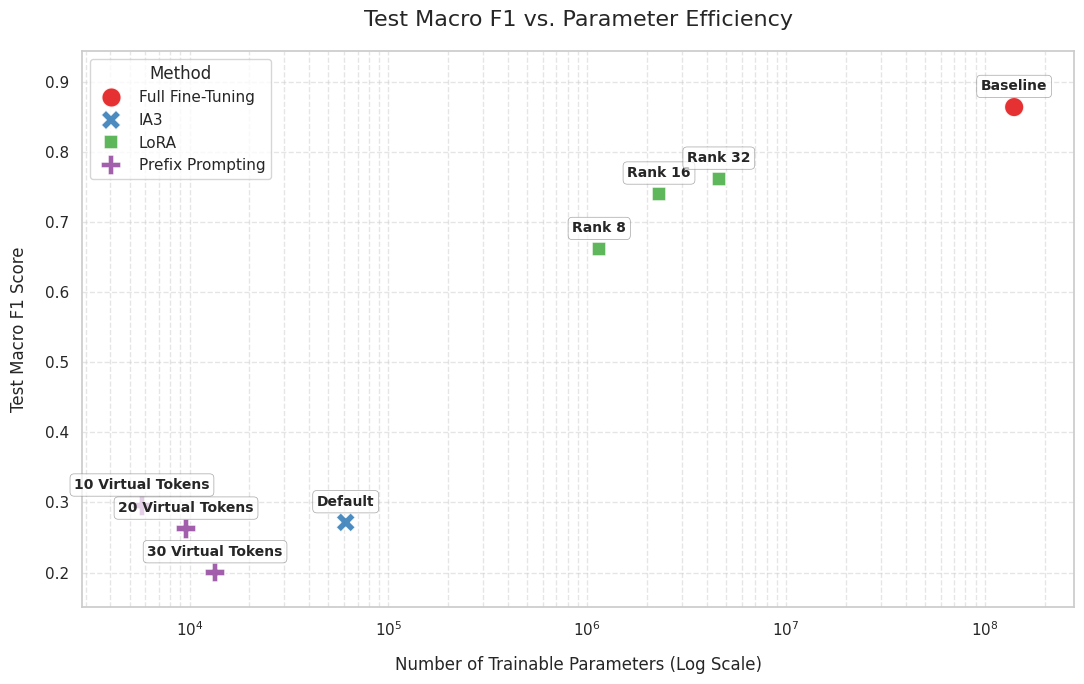

In [3]:
plt.figure(figsize=(11, 7))

# Scatter plot
sns.scatterplot(
    data=df_results,
    x='Trainable Params',
    y='Test Macro F1',
    hue='Method',
    style='Method',
    s=200,
    palette='Set1',
    alpha=0.9
)

# Annotation of individual points
for idx, row in df_results.iterrows():
    plt.annotate(
        row['Configuration'],
        (row['Trainable Params'], row['Test Macro F1']),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=10,
        weight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="gray", lw=0.5)
)

plt.xscale('log')
plt.xlabel('Number of Trainable Parameters (Log Scale)', labelpad=12)
plt.ylabel('Test Macro F1 Score', labelpad=12)
plt.title('Test Macro F1 vs. Parameter Efficiency', pad=18, fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlim(df_results['Trainable Params'].min() * 0.5, df_results['Trainable Params'].max() * 2)
plt.ylim(df_results['Test Macro F1'].min() - 0.05, df_results['Test Macro F1'].max() + 0.08)
plt.tight_layout()

plt.savefig(os.path.join(results_dir, 'fig_peft_comparison.png'), dpi=300)
plt.show()

## 4. Compare LoRA across Ranks 8, 16, and 32
In this section, we analyze the effect of scaling the low-rank adaptation dimension ($r$) on classification performance, parameter count, and training duration.

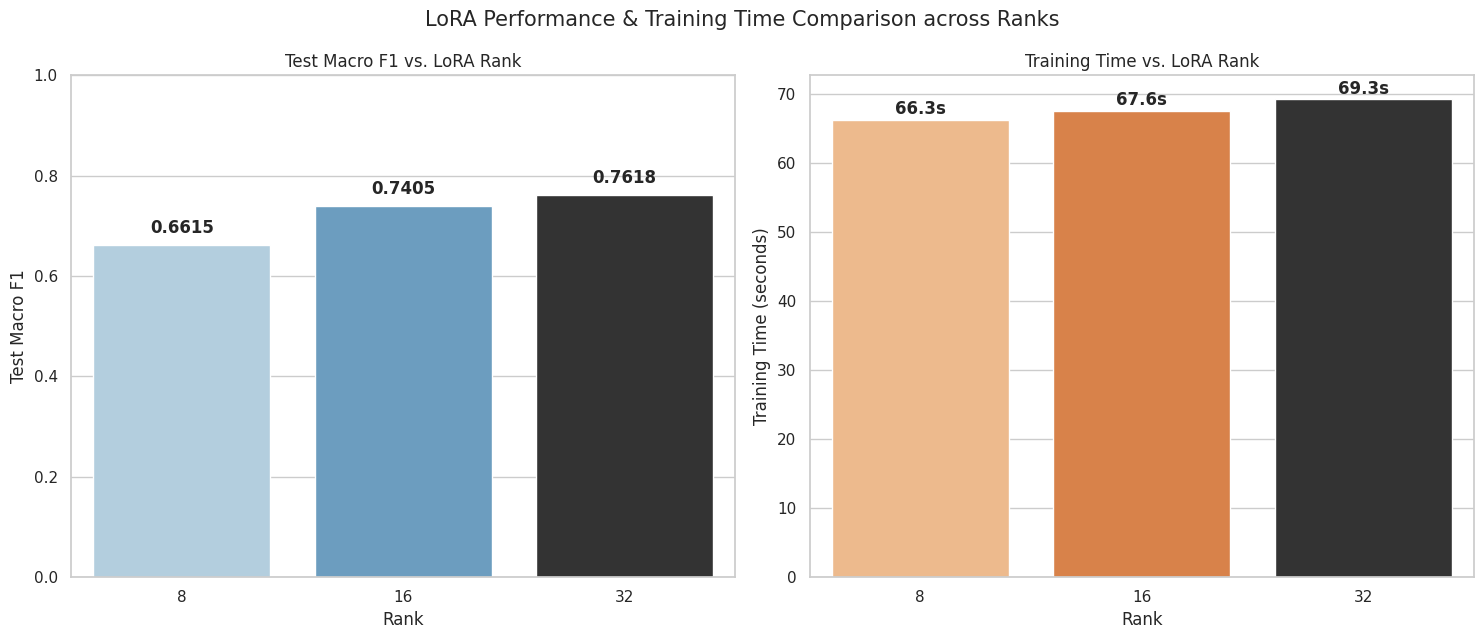

,Rank,Trainable Params,Trainable %,Best Val Macro F1,Test Macro F1,Training Time (s)
0,8,1150853,0.811636,0.676541,0.661465,66.311663
1,16,2299781,1.608877,0.735042,0.740524,67.613179
2,32,4597637,3.165521,0.784661,0.761796,69.259870


In [4]:
def extract_number(val):

    nums = re.findall(r'\d+', str(val))
    if nums:
        return int(nums[0])
    return 0

df_lora = df_results[df_results['Method'] == 'LoRA'].copy()
df_lora['Rank'] = df_lora['ParamsRaw'].apply(extract_number)
df_lora = df_lora.sort_values(by='Rank').reset_index(drop=True)

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# 1. Test Macro F1 vs Rank
sns.barplot(data=df_lora, x='Rank', y='Test Macro F1', ax=axes[0], hue='Rank', palette='Blues_d', legend=False)
axes[0].set_title('Test Macro F1 vs. LoRA Rank')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Test Macro F1')
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

# 2. Training time vs Rank
sns.barplot(data=df_lora, x='Rank', y='Training Time (s)', ax=axes[1], hue='Rank', palette='Oranges_d', legend=False)
axes[1].set_title('Training Time vs. LoRA Rank')
axes[1].set_ylabel('Training Time (seconds)')
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.1f}s", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

plt.suptitle('LoRA Performance & Training Time Comparison across Ranks', y=0.98, fontsize=15)
plt.tight_layout()
plt.show()

df_lora[['Rank', 'Trainable Params', 'Trainable %', 'Best Val Macro F1', 'Test Macro F1', 'Training Time (s)']]

### LoRA Rank Comparison Analysis & Discussion
- **Accuracy Scaling**: Increasing the LoRA rank yields a direct positive correlation with the Test Macro F1 score. Rank 8 gets a Test Macro F1 of **0.6615**, rank 16 achieves **0.7405**, and rank 32 achieves **0.7618**. Scaling from 8 to 16 gives a large gain (+0.079), while going from 16 to 32 shows a smaller, though still solid, improvement (+0.021).
- **Parameter Cost**: The parameter count scales linearly with the rank. LoRA with $r=8$ requires **1.15M** trainable parameters (0.81% of base model). This increases to **2.30M** at $r=16$ (1.61% of base model) and **4.60M** at $r=32$ (3.17% of base model).
- **Training Overhead**: Despite the quadrupled parameter size between $r=8$ and $r=32$, the training time remains extremely stable (approx. **66.3s** for $r=8$ vs. **69.3s** for $r=32$). This indicates that modern GPU training is highly parallelized and that the minor overhead of computing larger low-rank matrices does not bottleneck the compute time.

### LoRA Per-Class F1 Score Comparison Across Ranks
To understand what categories drive the overall performance scaling in LoRA, we compare the individual classification quality (Test F1 Score) for each of the five news classes across the three ranks (8, 16, 32).

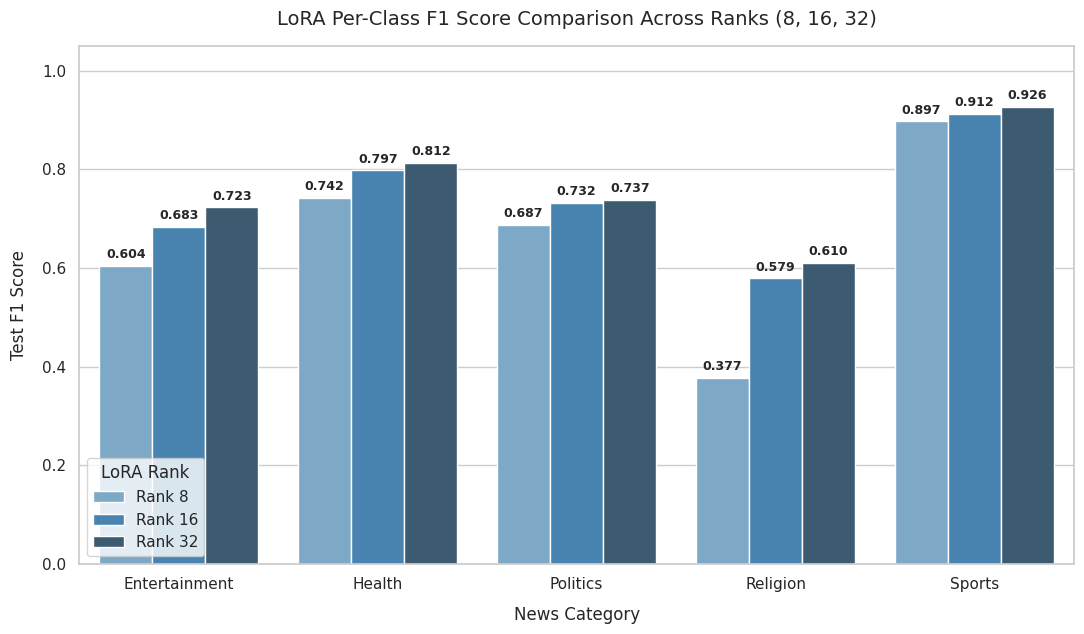

In [5]:
# Extract per-class F1 for LoRA ranks
lora_classes = []
for name, data in results.items():
    if name.startswith('peft_lora_'):
        rank_val = extract_number(data['parameters'])
        for cat, val in data['per_class_f1'].items():
            lora_classes.append({
                'Rank': f'Rank {rank_val}',
                'Category': cat.capitalize(),
                'Test F1 Score': val
            })



df_lora_classes = pd.DataFrame(lora_classes)
df_lora_classes['Rank_num'] = df_lora_classes['Rank'].apply(extract_number)
df_lora_classes = df_lora_classes.sort_values(by=['Category', 'Rank_num']).reset_index(drop=True)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(
    data=df_lora_classes,
    x='Category',
    y='Test F1 Score',
    hue='Rank',
    palette='Blues_d'
)





plt.title('LoRA Per-Class F1 Score Comparison Across Ranks (8, 16, 32)', pad=15, fontsize=14)
plt.ylabel('Test F1 Score', labelpad=10)
plt.xlabel('News Category', labelpad=10)
plt.ylim(0, 1.05)
plt.legend(title='LoRA Rank', loc='lower left')



# Annotate bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='bold'
        )

plt.tight_layout()


plt.show()

## 5. Compare Prefix Prompting against Virtual Prompt Lengths 10, 20, and 30
In this section, we study how prefix tuning performance responds to the length of the virtual prompt segment inserted in front of the sequence.

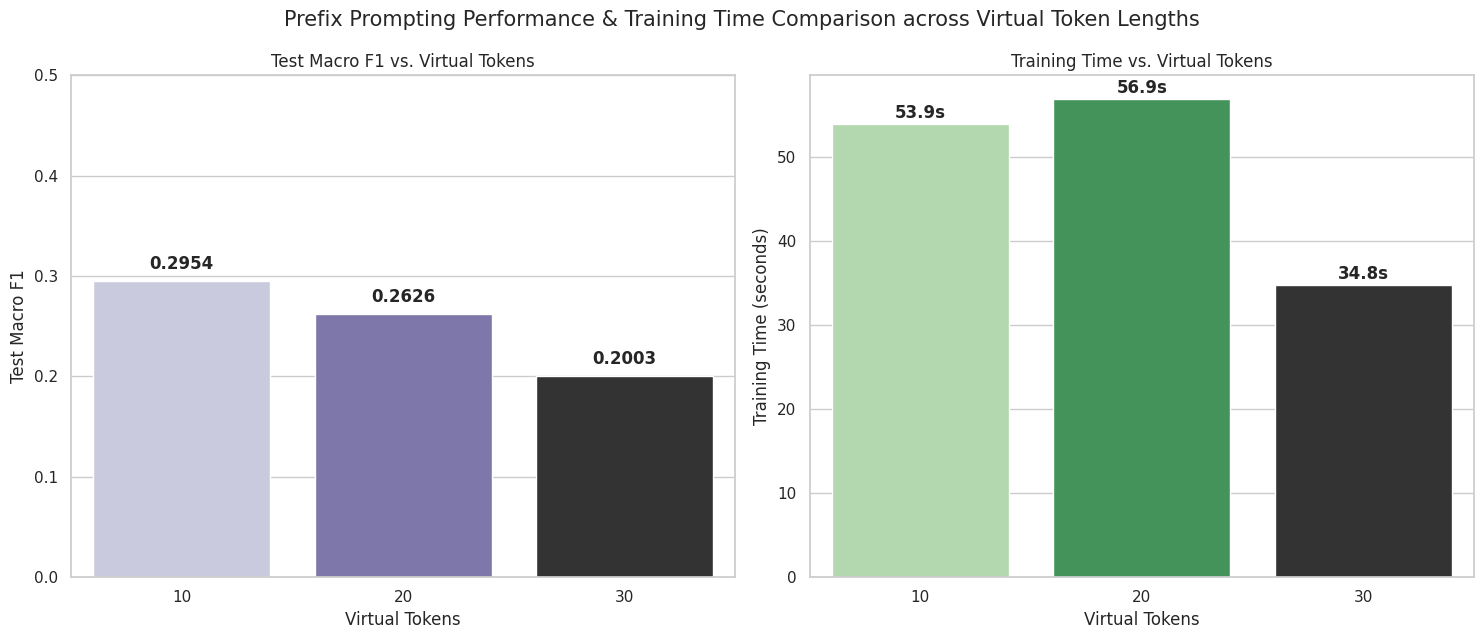

,Virtual Tokens,Trainable Params,Trainable %,Best Val Macro F1,Test Macro F1,Training Time (s)
0,10,5765,0.004099,0.297621,0.295443,53.941316
1,20,9605,0.006829,0.255368,0.262551,56.864858
2,30,13445,0.009559,0.153348,0.200281,34.773026


In [6]:
df_prefix = df_results[df_results['Method'] == 'Prefix Prompting'].copy()
df_prefix['Virtual Tokens'] = df_prefix['ParamsRaw'].apply(extract_number)
df_prefix = df_prefix.sort_values(by='Virtual Tokens').reset_index(drop=True)

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))



# 1. Test F1 vs Virtual Tokens
sns.barplot(data=df_prefix, x='Virtual Tokens', y='Test Macro F1', ax=axes[0], hue='Virtual Tokens', palette='Purples_d', legend=False)
axes[0].set_title('Test Macro F1 vs. Virtual Tokens')
axes[0].set_ylim(0, 0.5)
axes[0].set_ylabel('Test Macro F1')
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f"{p.get_height():.4f}", 
            (p.get_x() + p.get_width() / 2., 
             p.get_height() + 0.01),
                        ha='center', 
                        va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points', 
                        weight='bold'
            )




# 2. Training time vs Virtual Tokens
sns.barplot(data=df_prefix, x='Virtual Tokens', y='Training Time (s)', ax=axes[1], hue='Virtual Tokens', palette='Greens_d', legend=False)
axes[1].set_title('Training Time vs. Virtual Tokens')
axes[1].set_ylabel('Training Time (seconds)')
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(
            f"{p.get_height():.1f}s", 
            (p.get_x() + p.get_width() / 2.,
              p.get_height() + 0.5),
                        ha='center', 
                        va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points', 
                        weight='bold'
            )



plt.suptitle('Prefix Prompting Performance & Training Time Comparison across Virtual Token Lengths', y=0.98, fontsize=15)
plt.tight_layout()
plt.show()

df_prefix[['Virtual Tokens', 'Trainable Params', 'Trainable %', 'Best Val Macro F1', 'Test Macro F1', 'Training Time (s)']]

### Prefix Prompting Length Comparison Analysis & Discussion
- **Underfitting and Performance Decay**: Prefix Prompting shows a significant decline in classification quality compared to LoRA, and it degrades further as token length increases. Length 10 achieves **0.2954** Test Macro F1, length 20 gets **0.2626**, and length 30 falls to **0.2003**. This is because Prefix Prompting only trains the prepended virtual key-value prompt states, which struggles to adapt the deeply multi-lingual representations of mmBERT-small on MasakhaNews without full internal weight tuning. Furthermore, longer prompt lengths lead to early stopping: length 30 early-stopped at Epoch 3 (after only 34.8 seconds of training) because validation performance failed to improve, indicating severe training instability or optimization issues for this sequence classification task.
- **Extreme Parameter Efficiency**: In terms of parameter footprint, Prefix Prompting is outstanding. It only adds between **5.7K** ($v=10$) and **13.4K** ($v=30$) trainable parameters. This translates to an efficiency of **0.004% to 0.010%** of the model parameters. While extremely light, the trade-off in accuracy is severe on this downstream task.

### Prefix Prompting Per-Class F1 Score Comparison Across Virtual Prompt Lengths
Similarly, we analyze how changing the virtual prompt token length (10, 20, 30) influences individual class performance.

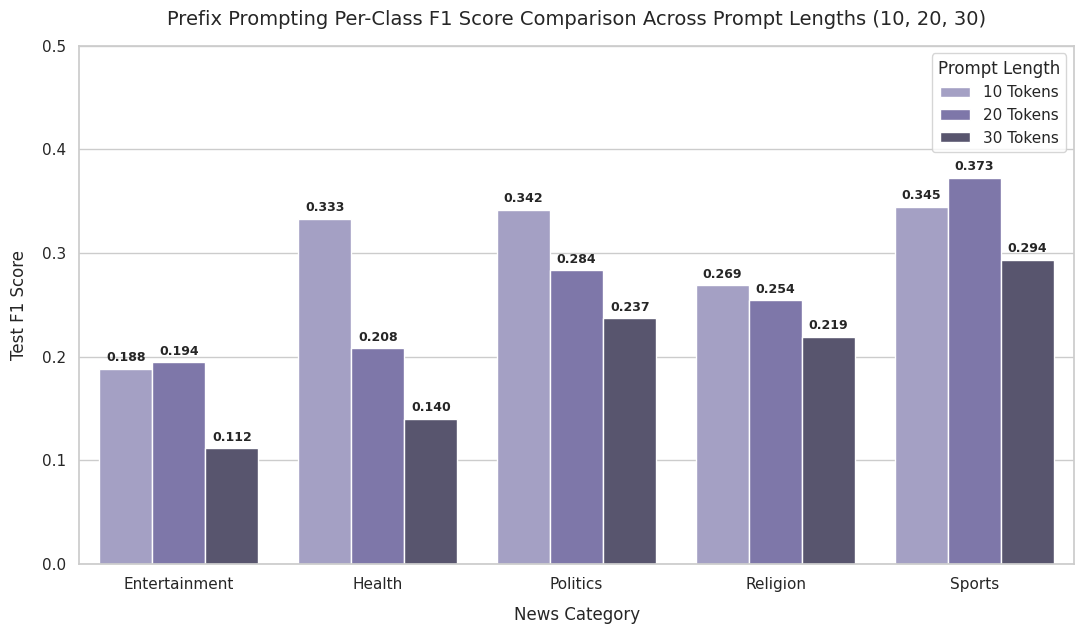

In [7]:
# Extract per-class F1 for Prefix Prompting lengths
prefix_classes = []
for name, data in results.items():
    if name.startswith('peft_prompt_'):
        len_val = extract_number(data['parameters'])
        for cat, val in data['per_class_f1'].items():
            prefix_classes.append({
                'Prompt Length': f'{len_val} Tokens',
                'Category': cat.capitalize(),
                'Test F1 Score': val
            })

df_prefix_classes = pd.DataFrame(prefix_classes)
df_prefix_classes['Length_num'] = df_prefix_classes['Prompt Length'].apply(extract_number)
df_prefix_classes = df_prefix_classes.sort_values(by=['Category', 'Length_num']).reset_index(drop=True)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(
    data=df_prefix_classes,
    x='Category',
    y='Test F1 Score',
    hue='Prompt Length',
    palette='Purples_d'
)
plt.title('Prefix Prompting Per-Class F1 Score Comparison Across Prompt Lengths (10, 20, 30)', pad=15, fontsize=14)
plt.ylabel('Test F1 Score', labelpad=10)
plt.xlabel('News Category', labelpad=10)
plt.ylim(0, 0.5)
plt.legend(title='Prompt Length', loc='upper right')

# Annotate bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points', 
            fontsize=9, 
            weight='bold'
        )




plt.tight_layout()
plt.show()

## 6. Detailed Error Analysis and Discussion
We compile the class-level performance drops between the Full Fine-Tuning Baseline and the best PEFT configurations to see exactly where PEFT methods underperform.

In [8]:
# Baseline vs. LoRA Rank 32 vs. Prefix Prompting v10, compare by class
baseline_per_class = results.get('news_baseline', {}).get('per_class_f1', {})
lora_r32_per_class = results.get('peft_lora_r32', {}).get('per_class_f1', {})
prompt_v10_per_class = results.get('peft_prompt_v10', {}).get('per_class_f1', {})

if baseline_per_class and lora_r32_per_class:
    error_rows = []
    for cat in sorted(baseline_per_class.keys()):
        base_f1 = baseline_per_class[cat]
        lora_f1 = lora_r32_per_class[cat]
        prompt_f1 = prompt_v10_per_class.get(cat, 0.0)
        
        error_rows.append({
            'Category': cat.capitalize(),
            'Baseline F1': base_f1,
            'LoRA R32 F1': lora_f1,
            'LoRA Drop (Abs)': base_f1 - lora_f1,
            'Prompt V10 F1': prompt_f1,
            'Prompt Drop (Abs)': base_f1 - prompt_f1
        })
        
    df_error = pd.DataFrame(error_rows)
    styled_error = df_error.style.format({
        'Baseline F1': '{:.4f}',
        'LoRA R32 F1': '{:.4f}',
        'LoRA Drop (Abs)': '{:.4f}',
        'Prompt V10 F1': '{:.4f}',
        'Prompt Drop (Abs)': '{:.4f}'
    })
    display(styled_error)
else:
    print('Baseline or LoRA R32 results missing.')

,Category,Baseline F1,LoRA R32 F1,LoRA Drop (Abs),Prompt V10 F1,Prompt Drop (Abs)
0,Entertainment,0.8254,0.7225,0.1029,0.1885,0.6369
1,Health,0.8537,0.8125,0.0412,0.3333,0.5203
2,Politics,0.8571,0.7373,0.1198,0.3417,0.5155
3,Religion,0.8065,0.6102,0.1963,0.2689,0.5375
4,Sports,0.9778,0.9265,0.0513,0.3448,0.6330


### Key Findings from Error Analysis

1. **Easy classes keep performance**: The Sports and Health categories are the easiest to classify across configurations, with the minimal performance drops occurring with the LoRA method. The baseline F1 is recorded at a high **0.9778**, and a minimal drop is found to occur for LoRA with rank 32. It is speculated then that language in the sports category has highly distinctive and specialised vocabulary, which makes it easy to identify even with low-rank weight updates.
2. **Challenging Classes experience severe degradation:** Religion and entertainment are categories that represent more abstract concepts, and therefore, the language used can be frequently found in other categories. While the baseline F1 records an accuracy score of **0.8065** for religion, the category experiences a significant drop to **0.6102** for LoRA at rank 32.
3. **Prefix prompting failure:** Prefix prompting appeared to not perform well at all across the PEFT methods. Since prefix prompting leaves all pre-trained layers frozen and only tuns the virtual prompt keys/values, the model struggles to align the current dataset with its internal vocabulary of Yorobu; the baseline model is a multilingual model, and since it is relatively small, it’s Yorobu vocabulary is too shallow for prefix prompting to provide much value. 
4. **The capacity matters:** The increase in rank for LoRA appears to mitigate the losses incurred compared to the baseline F1. Going from rank 8 to rank 32, the accuracy rises from 0.3774 to 0.6102, which shows that more complex, ambiguous categories require higher rank parameter matrices to allow for extra expressiveness.

